# SketchCritic Model Evaluation

This notebook evaluates the saved MLP and Random Forest on the CSV data.

In [148]:
from pathlib import Path
import pickle

import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score

In [149]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "sketchcritic_synthetic.csv"
MLP_PATH = PROJECT_ROOT / "models" / "sketchcritic_mlp.pkl"
RF_PATH = PROJECT_ROOT / "models" / "sketchcritic_rf.pkl"

DATA_PATH, MLP_PATH, RF_PATH

(WindowsPath('c:/Users/rache/OneDrive/Desktop/Duke/cs 372/Final Project/SketchCritic/data/sketchcritic_synthetic.csv'),
 WindowsPath('c:/Users/rache/OneDrive/Desktop/Duke/cs 372/Final Project/SketchCritic/models/sketchcritic_mlp.pkl'),
 WindowsPath('c:/Users/rache/OneDrive/Desktop/Duke/cs 372/Final Project/SketchCritic/models/sketchcritic_rf.pkl'))

In [150]:
data = pd.read_csv(DATA_PATH)
label_columns = [column for column in data.columns if column.startswith("label_")]
feature_columns = [column for column in data.columns if column not in label_columns and column != "active_labels"]

X = data[feature_columns]
y = data[label_columns]

print(f"Rows: {len(data)}")
print(f"Features: {len(feature_columns)}")
print(f"Labels: {len(label_columns)}")

Rows: 194
Features: 22
Labels: 20


In [151]:
def load_artifact(path: Path) -> dict:
    with path.open("rb") as handle:
        return pickle.load(handle)


def evaluate_artifact(path: Path) -> dict:
    artifact = load_artifact(path)
    model = artifact["model"]
    feature_names = artifact["feature_names"]
    label_names = artifact["label_names"]

    X_eval = data[feature_names]
    y_eval = data[label_names]
    y_pred = model.predict(X_eval)
    report_df = pd.DataFrame(
        classification_report(
            y_eval,
            y_pred,
            target_names=label_names,
            zero_division=0,
            output_dict=True,
        )
    ).T.drop(columns=["support"], errors="ignore")

    return {
        "model_path": str(path),
        "exact_match_accuracy": accuracy_score(y_eval, y_pred),
        "precision": precision_score(y_eval, y_pred, average="micro", zero_division=0),
        "recall": recall_score(y_eval, y_pred, average="micro", zero_division=0),
        "micro_f1": f1_score(y_eval, y_pred, average="micro", zero_division=0),
        "macro_f1": f1_score(y_eval, y_pred, average="macro", zero_division=0),
        "classification_report": report_df,
    }

In [152]:
mlp_results = evaluate_artifact(MLP_PATH)
rf_results = evaluate_artifact(RF_PATH)

summary = pd.DataFrame([
    {
        "model": "MLP",
        "exact_match_accuracy": mlp_results["exact_match_accuracy"],
        "precision": mlp_results["precision"],
        "recall": mlp_results["recall"],
        "micro_f1": mlp_results["micro_f1"],
        "macro_f1": mlp_results["macro_f1"],
    },
    {
        "model": "Random Forest",
        "exact_match_accuracy": rf_results["exact_match_accuracy"],
        "precision": rf_results["precision"],
        "recall": rf_results["recall"],
        "micro_f1": rf_results["micro_f1"],
        "macro_f1": rf_results["macro_f1"],
    },
])

summary

,model,exact_match_accuracy,precision,recall,micro_f1,macro_f1
0,MLP,0.072165,0.335165,0.225926,0.269912,0.124261
1,Random Forest,0.969072,1.000000,0.977778,0.988764,0.977985


In [153]:
print("MLP classification report")
print(mlp_results["classification_report"])

print("Random Forest classification report")
print(rf_results["classification_report"])

MLP classification report
                                                 precision    recall  f1-score
label_balanced                                    0.000000  0.000000  0.000000
label_middle_lower_vertical_imbalance             0.250000  0.375000  0.300000
label_nose_misaligned                             0.000000  0.000000  0.000000
label_nose_too_high                               0.000000  0.000000  0.000000
label_nose_too_low                                0.000000  0.000000  0.000000
label_mouth_misaligned                            0.000000  0.000000  0.000000
label_mouth_too_high                              0.000000  0.000000  0.000000
label_mouth_too_low                               0.000000  0.000000  0.000000
label_nose_too_narrow_relative_to_inner_eye_gap   0.727273  1.000000  0.842105
label_nose_too_wide_relative_to_inner_eye_gap     0.000000  0.000000  0.000000
label_nose_appears_large                          0.000000  0.000000  0.000000
label_mouth_appears_wide  

## Model Improvement Log

In [154]:
experiment_results = pd.DataFrame([
    {
        "model": "Random Forest",
        "hyperparameter": "n_estimators",
        "Iteration": "1",
        "value": "50",
        "accuracy": 0.7436,
        "precision": 0.9773,
        "recall": 0.8113,
        "f1": 0.8866,
    },
    {
        "model": "Random Forest",
        "hyperparameter": "n_estimators",
        "Iteration": "2",
        "value": "200",
        "accuracy": 0.7949,
        "precision": 0.9783,
        "recall": 0.8491,
        "f1": 0.9091,
    }
])

experiment_results

,model,hyperparameter,Iteration,value,accuracy,precision,recall,f1
0,Random Forest,n_estimators,1,50,0.7436,0.9773,0.8113,0.8866
1,Random Forest,n_estimators,2,200,0.7949,0.9783,0.8491,0.9091


Increasing `n_estimators` from 50 to 200 improved accuracy, precision, recall, and f1, so iteration 2 is the stronger candidate which is what I used for my final model."

The two images below document the model-improvement comparison using 50 vs 200 estimators.

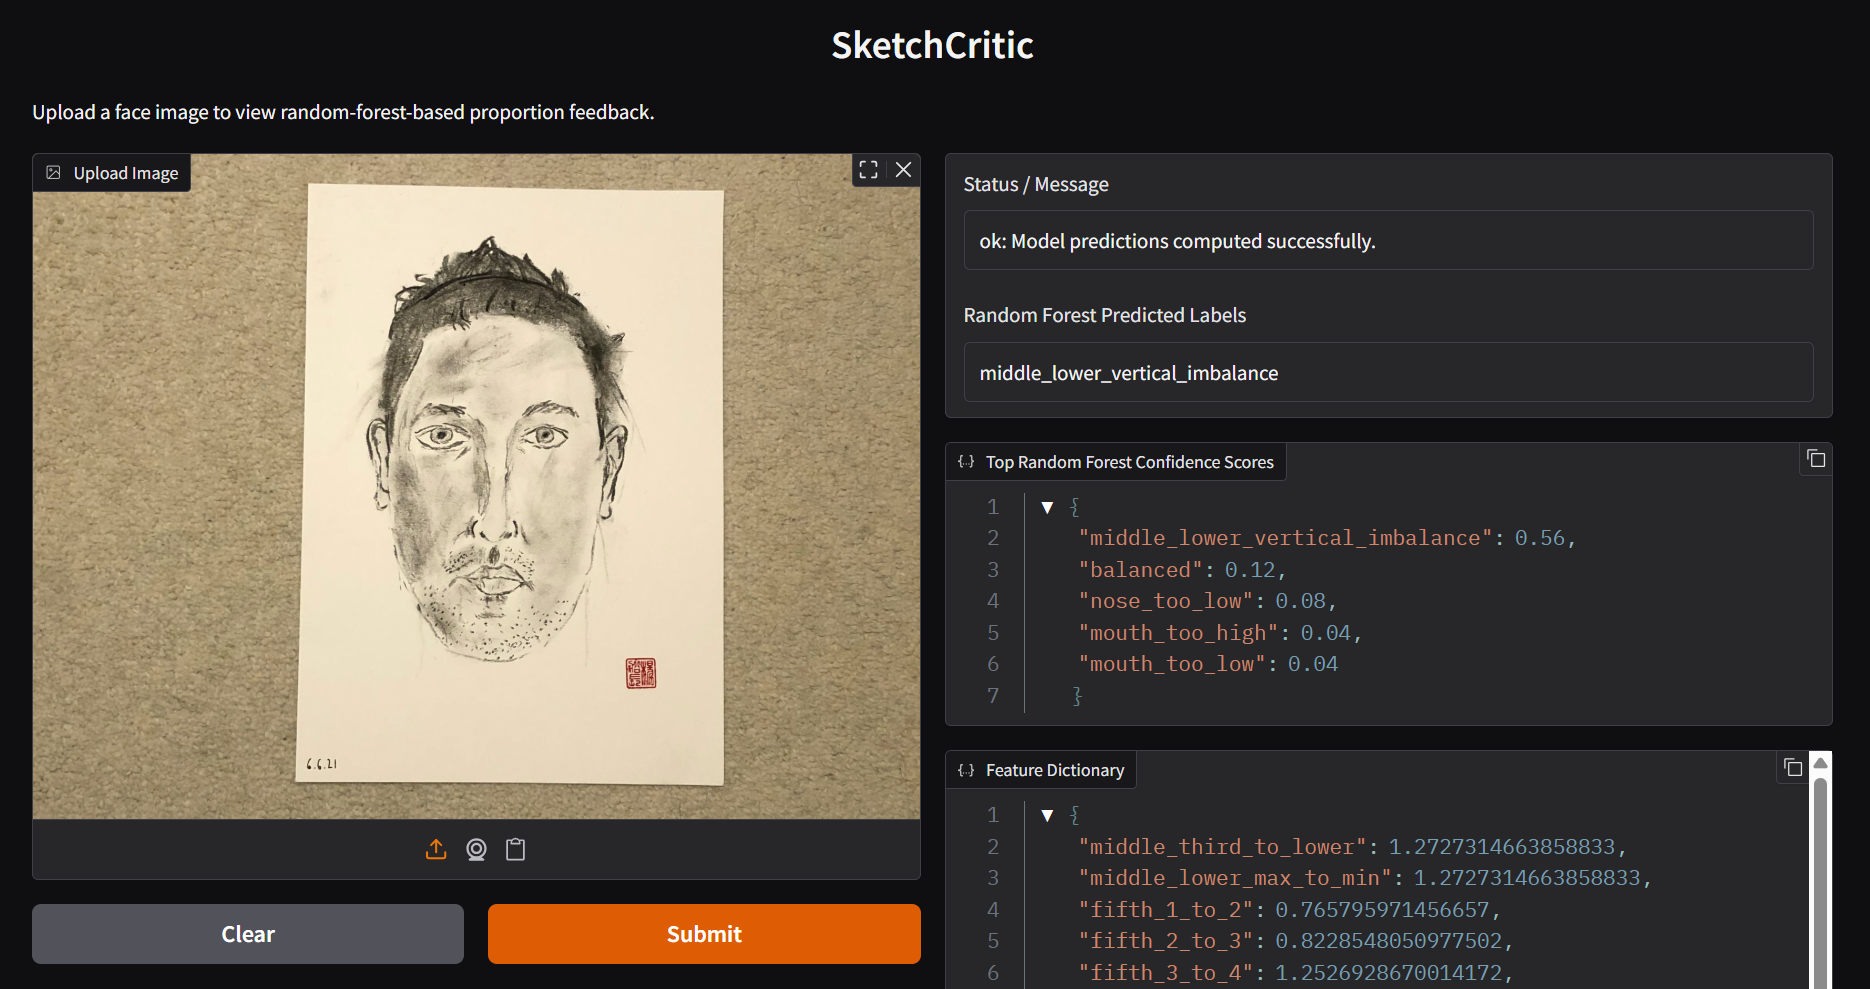

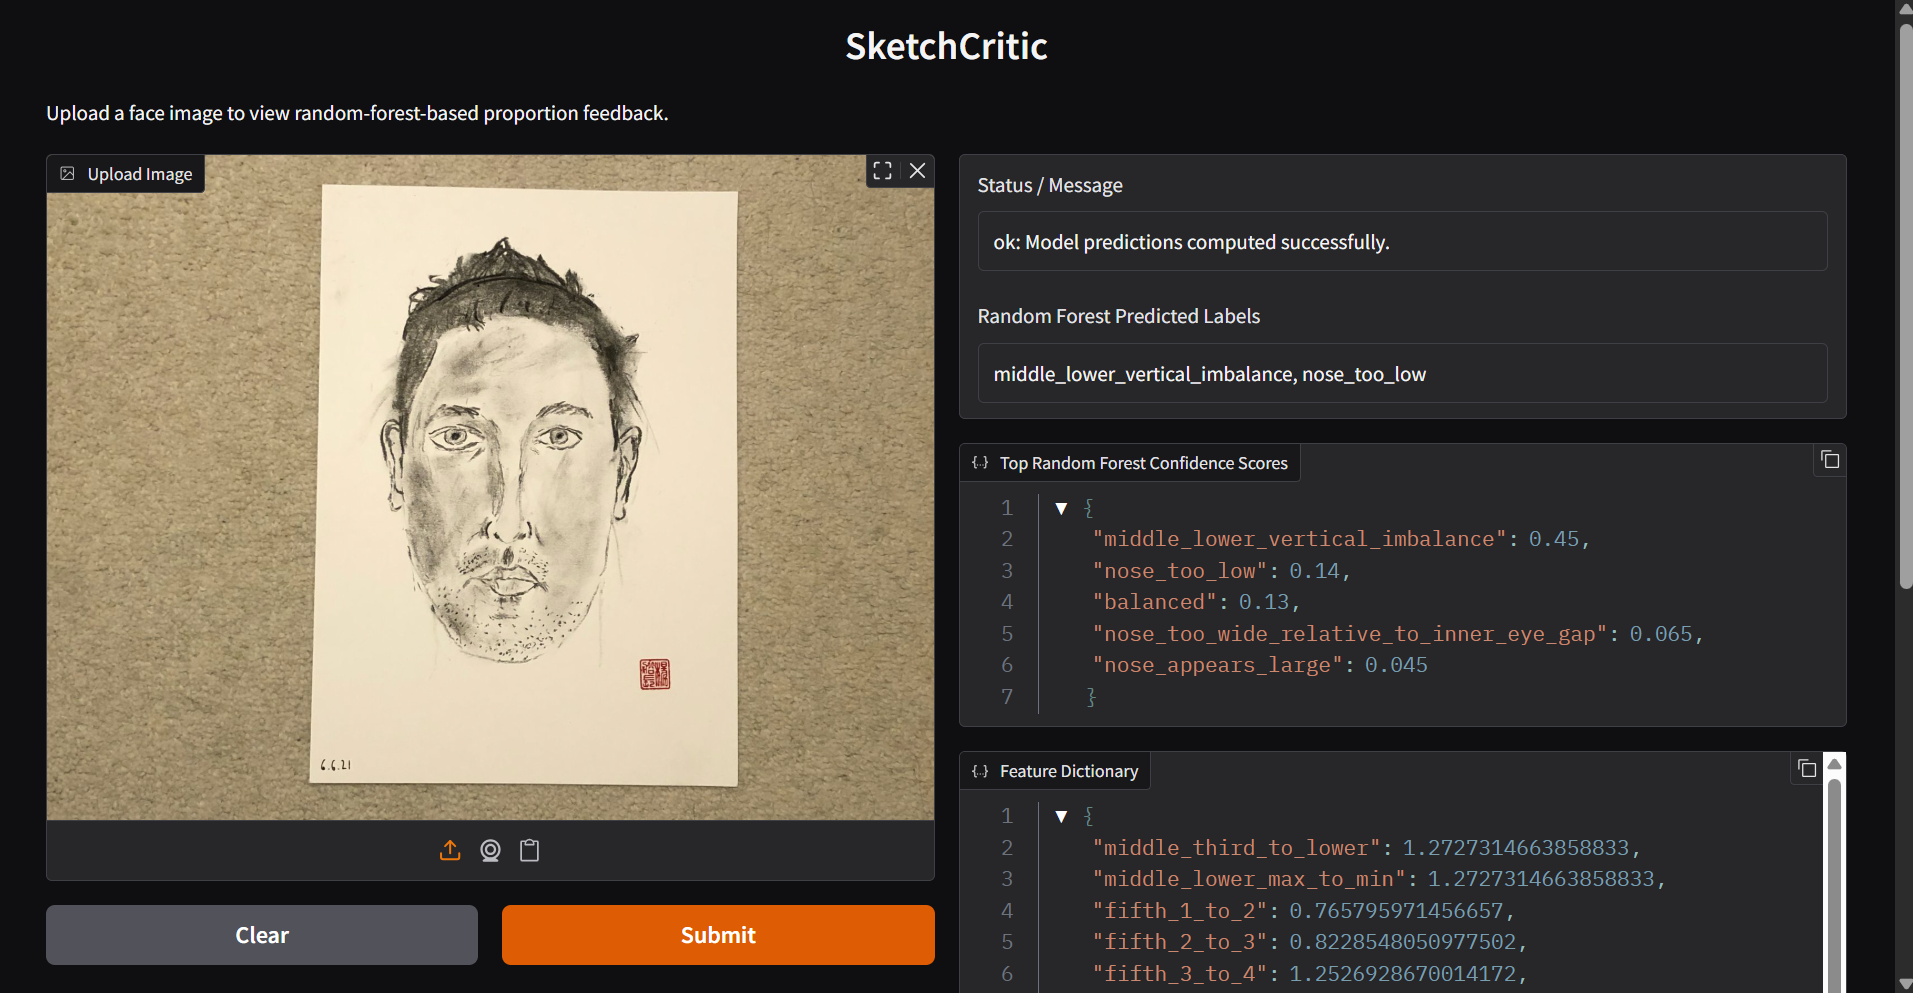

In [155]:
from IPython.display import Image, display

evidence_dir = PROJECT_ROOT / "notebooks" / "visual_evidence"
display(Image(filename=str(evidence_dir / "with_50_n_estimators.png")))
display(Image(filename=str(evidence_dir / "with_200_n_estimators.png")))

## Systematic Hyperparameter Tuning Evidence

This section compares at least three configurations using 3-fold cross-validation.

In [156]:
import sys

from sklearn.model_selection import KFold, cross_validate

sys.path.append(str(PROJECT_ROOT / "src"))

from train_mlp import create_model as create_mlp_model
from train_random_forest import create_model as create_rf_model

In [157]:
cv = KFold(n_splits=3, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_micro",
    "recall": "recall_micro",
    "f1": "f1_micro",
}

rf_configs = [
    {"n_estimators": 100, "max_depth": None},
    {"n_estimators": 150, "max_depth": None},
    {"n_estimators": 200, "max_depth": None},
]

rf_cv_results = []
for config in rf_configs:
    model = create_rf_model(random_state=42).set_params(**config)
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    rf_cv_results.append({
        "model": "Random Forest",
        "config": str(config),
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
    })

pd.DataFrame(rf_cv_results)

,model,config,accuracy,precision,recall,f1
0,Random Forest,"{'n_estimators': 100, 'max_depth': None}",0.654808,1.0,0.749767,0.856109
1,Random Forest,"{'n_estimators': 150, 'max_depth': None}",0.649599,1.0,0.746295,0.853933
2,Random Forest,"{'n_estimators': 200, 'max_depth': None}",0.665064,1.0,0.757610,0.861575


These values will be different from the above section for Model Improvement Log since the model improvement log was only evaluated on the test set not the whole dataset.

In [158]:
mlp_configs = [
    {"mlp__hidden_layer_sizes": (32,), "mlp__learning_rate_init": 0.001},
    {"mlp__hidden_layer_sizes": (64,), "mlp__learning_rate_init": 0.001},
    {"mlp__hidden_layer_sizes": (64, 32), "mlp__learning_rate_init": 0.0005},
]

mlp_cv_results = []
for config in mlp_configs:
    model = create_mlp_model(random_state=42).set_params(**config)
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    mlp_cv_results.append({
        "model": "MLP",
        "config": str(config),
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
    })

pd.DataFrame(mlp_cv_results)

,model,config,accuracy,precision,recall,f1
0,MLP,"{'mlp__hidden_layer_sizes': (32,), 'mlp__learn...",0.005128,0.095835,0.474286,0.154115
1,MLP,"{'mlp__hidden_layer_sizes': (64,), 'mlp__learn...",0.221875,0.614561,0.463349,0.524795
2,MLP,"{'mlp__hidden_layer_sizes': (64, 32), 'mlp__le...",0.000000,0.050452,0.280840,0.085526


## Random Forest Inference Efficiency

This section measures inference efficiency for the saved Random Forest model on the current dataset. It reports average batch inference time, average per-sample latency, and throughput in samples per second.



In [159]:
from time import perf_counter

rf_artifact = load_artifact(RF_PATH)
rf_model = rf_artifact["model"]
rf_feature_names = rf_artifact["feature_names"]
X_rf = data[rf_feature_names]
rf_model.predict(X_rf)

num_runs = 100
elapsed_times = []
for _ in range(num_runs):
    start = perf_counter()
    rf_model.predict(X_rf)
    elapsed_times.append(perf_counter() - start)

avg_batch_time_seconds = sum(elapsed_times) / len(elapsed_times)
avg_batch_time_milliseconds = avg_batch_time_seconds * 1000
avg_per_sample_milliseconds = (avg_batch_time_seconds / len(X_rf)) * 1000
throughput_samples_per_second = len(X_rf) / avg_batch_time_seconds

rf_efficiency_summary = pd.DataFrame([
    {
        "model": "Random Forest",
        "rows_evaluated": len(X_rf),
        "timed_runs": num_runs,
        "avg_batch_time_ms": round(avg_batch_time_milliseconds, 4),
        "avg_per_sample_ms": round(avg_per_sample_milliseconds, 6),
        "throughput_samples_per_second": round(throughput_samples_per_second, 2),
    }
])

rf_efficiency_summary

,model,rows_evaluated,timed_runs,avg_batch_time_ms,avg_per_sample_ms,throughput_samples_per_second
0,Random Forest,194,100,23.3806,0.120519,8297.46


The Random Forest model was evaluated for inference efficiency on 194 samples over 100 timed runs. Average batch inference time was 23.38 ms, average per-sample latency was 0.121 ms, and throughput was 8297.46 samples per second.